# 🧠 ML Pipeline Overview

1. **Load necessary libraries**  
   Import all required Python packages for data processing, model training, and evaluation.

2. **Load datasets**  
   Load and inspect all data splits:  
   - `train_df` — labeled data for training  
   - `val_df` — labeled data for validation (hyperparameter tuning)  
   - `test_df` — labeled data for final evaluation  
   - `unlabeled_df` — unlabeled data planned to be labeled using the trained model  

3. **Label-based fine-tuning of Transformer model**  
   Fine-tune `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` using **labeled training data**  
   to adapt the embeddings specifically for the classification task.

4. **Save fine-tuned model**  
   Store the trained Transformer model for reuse in embedding generation.

5. **Generate embeddings**  
   Encode all texts into dense vector representations using the fine-tuned Transformer.

6. **Save embeddings**  
   Save pre-computed embeddings to accelerate future training and analysis.

7. **Train and evaluate Logistic Regression on embeddings**  
   Train a baseline classifier on Transformer embeddings and evaluate its performance.

8. **Train and evaluate Logistic Regression on embeddings + TF-IDF**  
   Combine deep semantic embeddings with TF-IDF features to create a hybrid model and assess its performance.

9. **Grid Search for hyperparameter tuning**  
   Perform grid search optimization on the best-performing model to find optimal hyperparameters.

### 1. **Load necessary libraries**  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, classification_report
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
from itertools import product
import torch
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import plotly.express as px
import os
import joblib


### 2. **Load datasets** 

In [2]:
# Read the CSV file
train_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\train_df.csv", sep=';') # For training the model using labeled and augmented data

In [3]:
# Read the CSV file
test_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\test_df.csv", sep=';')# For final testing of the trained model

In [4]:
# Read the CSV file
val_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\labeled_df.csv", sep=';') # For validation (hyperparameter tuning with cross-validation) using labeled data without augmentation

In [5]:
# Read the CSV file
unlabeled_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\unlabeled_df.xls", sep=';') # DataFrame containing unlabeled data; planned to be labeled using the trained model

In [6]:
# Combine unlabeled_df and train_df into full_dataset
full_df = pd.concat([unlabeled_df, train_df], ignore_index=True)# For building the TF-IDF vocabulary
full_df = full_df.drop(columns=["Review Date"])
full_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024.0,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...,NaN,NaN,NaN,NaN,NaN
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023.0,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...,NaN,NaN,NaN,NaN,NaN
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023.0,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...,NaN,NaN,NaN,NaN,NaN
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022.0,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...,NaN,NaN,NaN,NaN,NaN
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021.0,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...,NaN,NaN,NaN,NaN,NaN


In [7]:
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

### 3. **Label-based fine-tuning of Transformer model** 
### 4. **Save fine-tuned model** 
### 5. **Generate embeddings**  
### 6. **Save embeddings**  

In [33]:
# =========================
# BLOCK 0: Imports & device
# =========================
os.makedirs("embeddings", exist_ok=True)  # створює папку, якщо її нема

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# BLOCK 1: Load base model
# =========================
# Transformer + Pooling
word_embedding_model = models.Transformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
base_model = SentenceTransformer(modules=[word_embedding_model, pooling_model]).to(device)

# =========================
# BLOCK 2: Fine-tuning setup
# =========================
import torch.nn as nn

embedding_dim = base_model.get_sentence_embedding_dimension()
num_classes = len(label_cols)

# Multi-label classifier
class MultiLabelClassifier(nn.Module):
    def __init__(self, base_model, embedding_dim, num_classes):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(embedding_dim, num_classes)
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, sentences, labels=None):
        embeddings = self.base_model.encode(
            sentences, convert_to_tensor=True, device=device
        )
        embeddings = embeddings.clone().detach().requires_grad_(True)
        logits = self.classifier(embeddings)
        if labels is not None:
            labels = torch.tensor(labels, dtype=torch.float, device=device)
            loss = self.loss_fn(logits, labels)
            return loss
        return logits

model = MultiLabelClassifier(base_model, embedding_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# =========================
# BLOCK 3: Fine-tuning loop
# =========================
num_epochs = 2
model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for text, label in zip(train_df["Cleaned_Text"], train_df[label_cols].values):
        optimizer.zero_grad()
        loss = model([text], [label.tolist()])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs} — Avg Loss: {total_loss/len(train_df):.4f}")

# =========================
# BLOCK 4: Save fine-tuned model
# =========================
save_path = "/content/drive/MyDrive/models/fine_tuned_mpnet"
base_model.save(save_path)
print(f"Model saved to: {save_path}")

# =========================
# BLOCK 5: Generate embeddings
# =========================
train_emb = base_model.encode(train_df["Cleaned_Text"], convert_to_numpy=True, show_progress_bar=True)
val_emb   = base_model.encode(val_df["Cleaned_Text"], convert_to_numpy=True, show_progress_bar=True)
test_emb  = base_model.encode(test_df["Cleaned_Text"], convert_to_numpy=True, show_progress_bar=True)

# =========================
# BLOCK 6: Save embeddings
# =========================
np.save("embeddings/train_embeddings.npy", train_emb)
np.save("embeddings/val_embeddings.npy", val_emb)
np.save("embeddings/test_embeddings.npy", test_emb)
print("Embeddings saved to disk.")



Epoch 1/2 — Avg Loss: 0.6793
Epoch 2/2 — Avg Loss: 0.6526
Model saved to: /content/drive/MyDrive/models/fine_tuned_mpnet


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embeddings saved to disk.


### 7. **Train and evaluate Logistic Regression on embeddings**

### Grid Search for hyperparameter tuning

Running l1_ratio=0.2, C=0.5
Running l1_ratio=0.2, C=1
Running l1_ratio=0.2, C=1.5
Running l1_ratio=0.2, C=2
Running l1_ratio=0.2, C=2.5
Running l1_ratio=0.3, C=0.5
Running l1_ratio=0.3, C=1
Running l1_ratio=0.3, C=1.5
Running l1_ratio=0.3, C=2
Running l1_ratio=0.3, C=2.5
Running l1_ratio=0.4, C=0.5
Running l1_ratio=0.4, C=1
Running l1_ratio=0.4, C=1.5
Running l1_ratio=0.4, C=2
Running l1_ratio=0.4, C=2.5
Running l1_ratio=0.5, C=0.5
Running l1_ratio=0.5, C=1
Running l1_ratio=0.5, C=1.5
Running l1_ratio=0.5, C=2
Running l1_ratio=0.5, C=2.5
Running l1_ratio=0.6, C=0.5
Running l1_ratio=0.6, C=1
Running l1_ratio=0.6, C=1.5
Running l1_ratio=0.6, C=2
Running l1_ratio=0.6, C=2.5
Running l1_ratio=0.7, C=0.5
Running l1_ratio=0.7, C=1
Running l1_ratio=0.7, C=1.5
Running l1_ratio=0.7, C=2
Running l1_ratio=0.7, C=2.5
Running l1_ratio=0.8, C=0.5
Running l1_ratio=0.8, C=1
Running l1_ratio=0.8, C=1.5
Running l1_ratio=0.8, C=2
Running l1_ratio=0.8, C=2.5


,l1_ratio,C,f1_micro_train,f1_micro_val
0,0.2,0.5,0.767583,0.690795
1,0.2,1.0,0.802346,0.684658
2,0.2,1.5,0.821992,0.687818
3,0.2,2.0,0.839937,0.688342
4,0.2,2.5,0.852015,0.684683
5,0.3,0.5,0.756825,0.683545
6,0.3,1.0,0.792256,0.687145
7,0.3,1.5,0.816368,0.688722
8,0.3,2.0,0.834003,0.687803
9,0.3,2.5,0.848333,0.683788


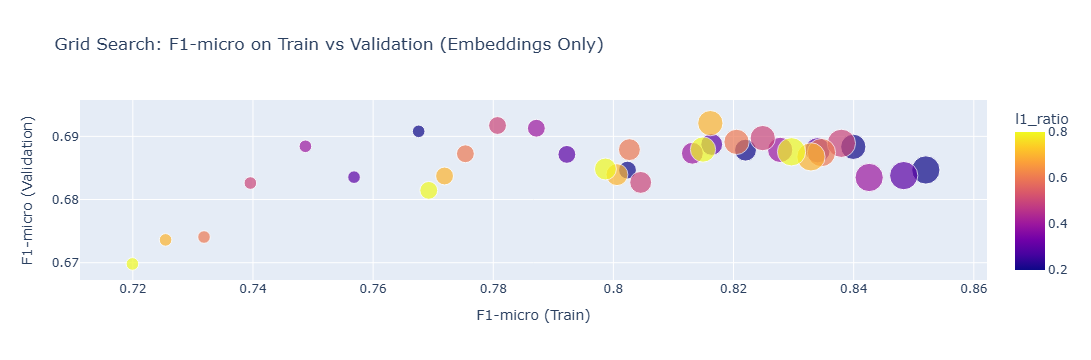

In [33]:
# -----------------------------
# Label columns
# -----------------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# -----------------------------
# Load precomputed embeddings (dense)
# -----------------------------
val_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/val_embeddings.npy")
y_labeled = val_df[label_cols].values

# -----------------------------
# Grid parameters
# -----------------------------
l1_ratios = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
Cs = [0.5, 1, 1.5, 2, 2.5]

# -----------------------------
# Store results
# -----------------------------
results = {"l1_ratio": [], "C": [], "f1_micro_train": [], "f1_micro_val": []}

# -----------------------------
# Grid search loop with K-Fold CV
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from itertools import product
import numpy as np
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for l1_ratio, C in product(l1_ratios, Cs):
    print(f"Running l1_ratio={l1_ratio}, C={C}")

    f1_train_list, f1_val_list = [], []

    for tr_idx, val_idx in kf.split(val_emb):
        X_tr, X_val_fold = val_emb[tr_idx], val_emb[val_idx]
        y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

        clf = OneVsRestClassifier(
            LogisticRegression(
                max_iter=3000,
                solver="saga",
                class_weight="balanced",
                penalty="elasticnet",
                l1_ratio=l1_ratio,
                C=C,
                random_state=42
            )
        )
        clf.fit(X_tr, y_tr)
        y_tr_pred = clf.predict(X_tr)
        y_val_pred = clf.predict(X_val_fold)

        f1_train_list.append(f1_score(y_tr, y_tr_pred, average="micro", zero_division=0))
        f1_val_list.append(f1_score(y_val_fold, y_val_pred, average="micro", zero_division=0))

    # Save averaged results
    results["l1_ratio"].append(l1_ratio)
    results["C"].append(C)
    results["f1_micro_train"].append(np.mean(f1_train_list))
    results["f1_micro_val"].append(np.mean(f1_val_list))

# -----------------------------
# Convert results dictionary to DataFrame
# -----------------------------
df_results = pd.DataFrame(results)
display(df_results)

# -----------------------------
# Optional: Interactive plot
# -----------------------------
import plotly.express as px

fig = px.scatter(
    df_results,
    x="f1_micro_train",
    y="f1_micro_val",
    color="l1_ratio",
    size="C",
    hover_data=["l1_ratio", "C"],
    title="Grid Search: F1-micro on Train vs Validation (Embeddings Only)"
)
fig.update_layout(
    xaxis_title="F1-micro (Train)",
    yaxis_title="F1-micro (Validation)"
)
fig.show()

#### Check model quality on validation set

In [12]:
# -----------------------------
# Label columns
# -----------------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# -----------------------------
# Load precomputed embeddings
# -----------------------------
val_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/val_embeddings.npy")
X_emb = val_emb 
y_labeled = val_df[label_cols].values

# -----------------------------
# K-Fold CV (embeddings only)
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all = []
y_pred_all = []

for tr_idx, val_idx in kf.split(X_emb):
    X_tr, X_val_fold = X_emb[tr_idx], X_emb[val_idx]
    y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.7,
            C=2,
            random_state=42
        )
    )

    clf.fit(X_tr, y_tr)

 
    y_val_pred = clf.predict(X_val_fold)

    
    y_val_all.append(y_val_fold)
    y_pred_all.append(y_val_pred)

# -----------------------------
# Aggregate results across folds
# -----------------------------
y_val_all = np.vstack(y_val_all)
y_pred_all = np.vstack(y_pred_all)

print("\n=== CV Classification Report (Embeddings only) ===")
print(classification_report(y_val_all, y_pred_all, target_names=label_cols, zero_division=0))

cv_micro = f1_score(y_val_all, y_pred_all, average="micro")
print(f"Aggregated CV micro-F1: {cv_micro:.4f}")



=== CV Classification Report (Embeddings only) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.59      0.70      0.64       145
          Campus_conditions       0.65      0.74      0.69       108
                 Corruption       0.72      0.77      0.74       133
Academic_Process_Management       0.62      0.73      0.67       130
          Education_Quality       0.68      0.76      0.71       184

                  micro avg       0.65      0.74      0.69       700
                  macro avg       0.65      0.74      0.69       700
               weighted avg       0.65      0.74      0.69       700
                samples avg       0.69      0.78      0.70       700

Aggregated CV micro-F1: 0.6921


#### Check model quality on training/test sets

In [32]:
# BLOCK 1: Load saved embeddings
train_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/train_embeddings.npy")
test_emb  = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/test_embeddings.npy")

# Load corresponding labels
label_cols = ["Attitude_Towards_Students",
              "Campus_conditions",
              "Corruption",
              "Academic_Process_Management",
              "Education_Quality"]

y_train = train_df[label_cols].values
y_test  = test_df[label_cols].values

# ================================
# BLOCK 2: Train classifier
# ================================
clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=0.7,
        C=2.0,
        random_state=42
    )
)

clf.fit(train_emb, y_train)

# ================================
# BLOCK 3: Evaluate
# ================================

# --- On train ---
y_train_pred = clf.predict(train_emb)
print("\n=== TRAIN SET RESULTS ===")
print(classification_report(y_train, y_train_pred, target_names=label_cols, digits=2))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred, average='micro'):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred, average='macro'):.3f}")

# --- On test ---
y_test_pred = clf.predict(test_emb)
print("\n=== TEST SET RESULTS ===")
print(classification_report(y_test, y_test_pred, target_names=label_cols, digits=2))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred, average='micro'):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")

# ================================
# BLOCK 4: Save model
# ================================
os.makedirs("models", exist_ok=True)
joblib.dump(clf, "models/logreg_classifier.pkl")
print("\n✅ Classifier saved to: models/logreg_classifier.pkl")




=== TRAIN SET RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.77      0.85      0.81       205
          Campus_conditions       0.73      0.91      0.81       108
                 Corruption       0.75      0.93      0.83       133
Academic_Process_Management       0.81      0.89      0.85       190
          Education_Quality       0.75      0.90      0.82       184

                  micro avg       0.77      0.89      0.82       820
                  macro avg       0.76      0.90      0.82       820
               weighted avg       0.77      0.89      0.82       820
                samples avg       0.81      0.91      0.84       820

Train Micro F1: 0.825
Train Macro F1: 0.824

=== TEST SET RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.61      0.61      0.61        31
          Campus_conditions       0.74      0.86      0.79        29
  

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.



### 8. **Train and evaluate Logistic Regression on embeddings + TF-IDF**  

#### TF-IDF Parameter Analysis for Model Training

In this analysis, we aim to understand the vocabulary overlap between **train** and **unlabeled** datasets and investigate how the choice of `min_df` (minimum document frequency) in the TF-IDF vectorizer affects vocabulary size and model performance.

The main goals are:

1. **Token Overlap Analysis:**  
   Compare the unique tokens in train vs. unlabeled datasets to estimate how many words are shared, and how many are exclusive to each set. This helps us understand if the train data covers the vocabulary used in unlabeled reviews.

2. **Vocabulary Size vs `min_df`:**  
   Test different `min_df` values to observe the trade-off between:
   - **Noise reduction:** removing very rare tokens that may not generalize well.
   - **Information loss:** avoiding the removal of valuable but infrequent features.

3. **Impact on Model Quality:**  
   Plot F1 scores (macro and micro) against `min_df` to select an optimal value that balances model performance and vocabulary size.

By combining these steps, we ensure that TF-IDF features capture meaningful signals without being overwhelmed by noise, providing a robust representation for downstream classification tasks.

#### Vocabulary Overlap Analysis (TF-IDF)

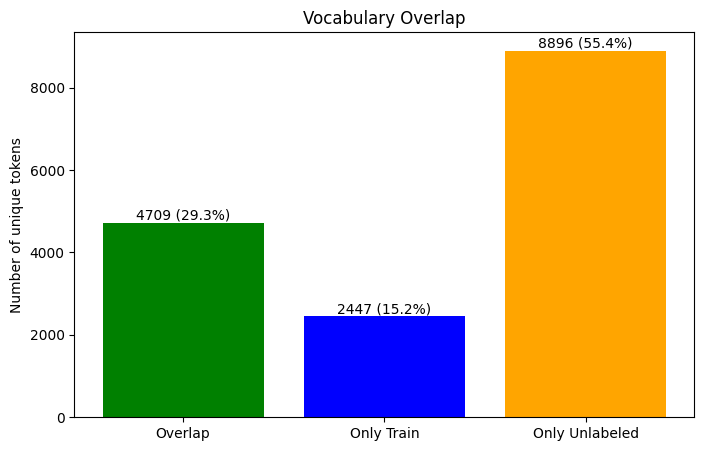

Full vocabulary size: 16052
Overlap tokens: 4709
Only in train: 2447
Only in unlabeled: 8896
Check sum: 16052


In [16]:
# -----------------------------
# 1️⃣ Prepare text lists
# -----------------------------
texts_train = train_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_unlabeled = unlabeled_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_full = full_df["Lemmatized_Text"].dropna().astype(str).tolist()

# -----------------------------
# 2️⃣ Build TF-IDF vocabulary on full corpus with n-grams
# -----------------------------
vectorizer = TfidfVectorizer(min_df=1)
vectorizer.fit(texts_full)
full_vocab = set(vectorizer.get_feature_names_out())

# Build analyzer to get the same tokenization for train/unlabeled
analyze = vectorizer.build_analyzer()

tokens_train = set()
for text in texts_train:
    tokens_train.update(analyze(text))

tokens_unlabeled = set()
for text in texts_unlabeled:
    tokens_unlabeled.update(analyze(text))

# -----------------------------
# 3️⃣ Compute overlap and unique tokens
# -----------------------------
overlap = full_vocab & tokens_train & tokens_unlabeled
only_train = (full_vocab & tokens_train) - tokens_unlabeled
only_unlabeled = (full_vocab & tokens_unlabeled) - tokens_train

# -----------------------------
# 4️⃣ Counts and percentages
# -----------------------------
total_tokens = len(full_vocab)
labels = ["Overlap", "Only Train", "Only Unlabeled"]
counts = [len(overlap), len(only_train), len(only_unlabeled)]
percentages = [c/total_tokens*100 for c in counts]

# -----------------------------
# 5️⃣ Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color=["green", "blue", "orange"])
plt.title("Vocabulary Overlap")
plt.ylabel("Number of unique tokens")

# Add count + percentage labels above bars
for i, (c, p) in enumerate(zip(counts, percentages)):
    plt.text(i, c + total_tokens*0.005, f"{c} ({p:.1f}%)", ha='center')

plt.show()

# -----------------------------
# 6️⃣ Summary
# -----------------------------
print("Full vocabulary size:", total_tokens)
print("Overlap tokens:", len(overlap))
print("Only in train:", len(only_train))
print("Only in unlabeled:", len(only_unlabeled))
print("Check sum:", len(overlap) + len(only_train) + len(only_unlabeled))


#### Vocabulary Size vs `min_df`

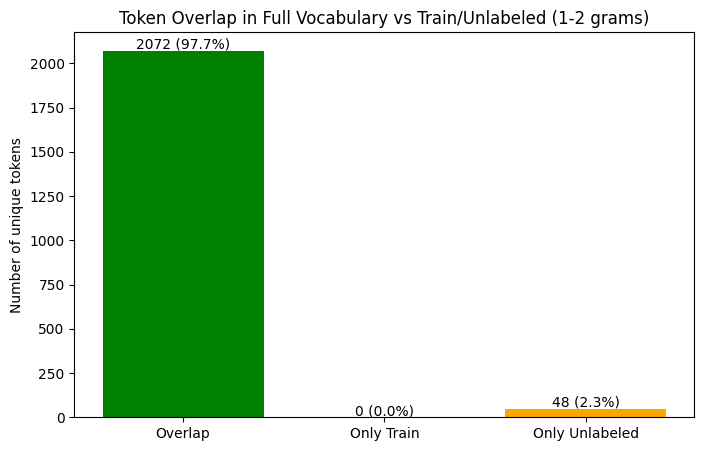

Full vocabulary size: 2120
Overlap tokens: 2072
Only in train: 0
Only in unlabeled: 48
Check sum: 2120


In [19]:
# -----------------------------
# 1️⃣ Prepare text lists
# -----------------------------
texts_train = train_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_unlabeled = unlabeled_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_full = full_df["Lemmatized_Text"].dropna().astype(str).tolist()

# -----------------------------
# 2️⃣ Build TF-IDF vocabulary on full corpus with n-grams
# -----------------------------
vectorizer = TfidfVectorizer(min_df=10, ngram_range=(1, 2))
vectorizer.fit(texts_full)
full_vocab = set(vectorizer.get_feature_names_out())

# Build analyzer to get the same tokenization for train/unlabeled
analyze = vectorizer.build_analyzer()

tokens_train = set()
for text in texts_train:
    tokens_train.update(analyze(text))

tokens_unlabeled = set()
for text in texts_unlabeled:
    tokens_unlabeled.update(analyze(text))

# -----------------------------
# 3️⃣ Compute overlap and unique tokens
# -----------------------------
overlap = full_vocab & tokens_train & tokens_unlabeled
only_train = (full_vocab & tokens_train) - tokens_unlabeled
only_unlabeled = (full_vocab & tokens_unlabeled) - tokens_train

# -----------------------------
# 4️⃣ Counts and percentages
# -----------------------------
total_tokens = len(full_vocab)
labels = ["Overlap", "Only Train", "Only Unlabeled"]
counts = [len(overlap), len(only_train), len(only_unlabeled)]
percentages = [c/total_tokens*100 for c in counts]

# -----------------------------
# 5️⃣ Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color=["green", "blue", "orange"])
plt.title("Token Overlap in Full Vocabulary vs Train/Unlabeled (1-2 grams)")
plt.ylabel("Number of unique tokens")

# Add count + percentage labels above bars
for i, (c, p) in enumerate(zip(counts, percentages)):
    plt.text(i, c + total_tokens*0.005, f"{c} ({p:.1f}%)", ha='center')

plt.show()

# -----------------------------
# 6️⃣ Summary
# -----------------------------
print("Full vocabulary size:", total_tokens)
print("Overlap tokens:", len(overlap))
print("Only in train:", len(only_train))
print("Only in unlabeled:", len(only_unlabeled))
print("Check sum:", len(overlap) + len(only_train) + len(only_unlabeled))


####  Compare how the vocabulary size changes with different min_df values
####  when using a TF-IDF vectorizer (with unigrams and bigrams)

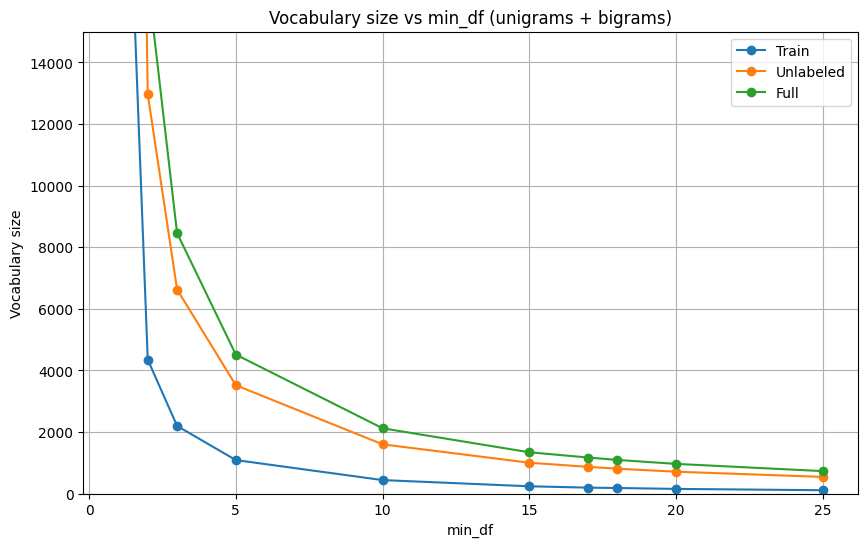

In [17]:
corpora = {
    "Train": train_df["Lemmatized_Text"].dropna().astype(str).tolist(),
    "Unlabeled": unlabeled_df["Lemmatized_Text"].dropna().astype(str).tolist(),
    "Full": full_df["Lemmatized_Text"].dropna().astype(str).tolist()
}

# New min_df values to test
min_dfs = [1, 2, 3, 5, 10, 15, 17, 18, 20, 25]
results = {name: [] for name in corpora}

# Compute vocabulary size for each min_df and corpus
for min_df in min_dfs:
    for name, texts in corpora.items():
        vectorizer = TfidfVectorizer(min_df=min_df, ngram_range=(1, 2))  # unigrams + bigrams
        vectorizer.fit(texts)
        vocab_size = len(vectorizer.vocabulary_)
        results[name].append(vocab_size)

# Plot vocabulary size vs min_df
plt.figure(figsize=(10,6))
for name, vocab_sizes in results.items():
    plt.plot(min_dfs, vocab_sizes, marker="o", label=name)

plt.title("Vocabulary size vs min_df (unigrams + bigrams)")
plt.xlabel("min_df")
plt.ylabel("Vocabulary size")
plt.ylim(0, 15000)  # limit to 15k
plt.legend()
plt.grid(True)
plt.show()


#### Impact on Model Quality


=== Evaluating min_df = 1 ===
Macro F1 = 0.6340, Micro F1 = 0.6343

=== Evaluating min_df = 2 ===
Macro F1 = 0.6354, Micro F1 = 0.6364

=== Evaluating min_df = 3 ===
Macro F1 = 0.6359, Micro F1 = 0.6349

=== Evaluating min_df = 5 ===
Macro F1 = 0.6458, Micro F1 = 0.6453

=== Evaluating min_df = 10 ===
Macro F1 = 0.6482, Micro F1 = 0.6488

=== Evaluating min_df = 15 ===
Macro F1 = 0.6533, Micro F1 = 0.6526

=== Evaluating min_df = 16 ===
Macro F1 = 0.6555, Micro F1 = 0.6556

=== Evaluating min_df = 17 ===
Macro F1 = 0.6523, Micro F1 = 0.6518

=== Evaluating min_df = 18 ===
Macro F1 = 0.6507, Micro F1 = 0.6503

=== Evaluating min_df = 19 ===
Macro F1 = 0.6486, Micro F1 = 0.6478

=== Evaluating min_df = 20 ===
Macro F1 = 0.6517, Micro F1 = 0.6503

=== Evaluating min_df = 25 ===
Macro F1 = 0.6450, Micro F1 = 0.6461


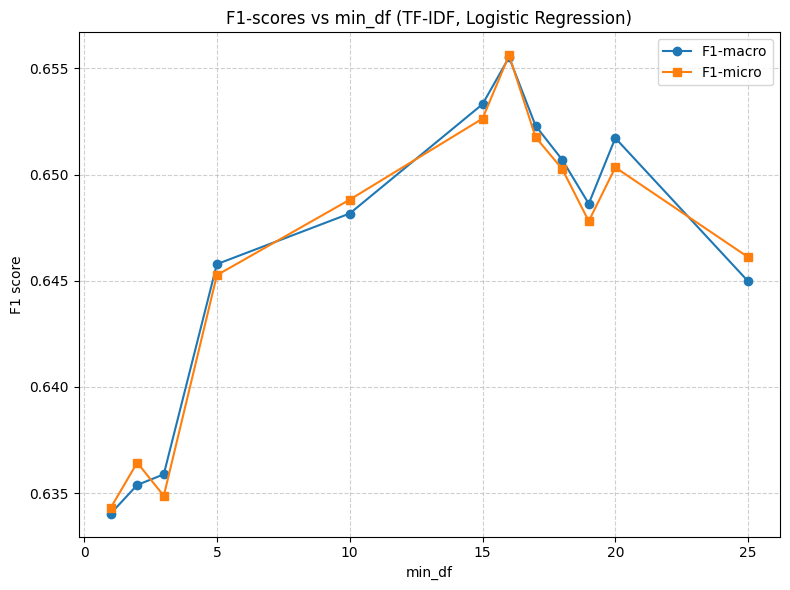

In [20]:

# Label columns (multi-label setup)
label_cols = ["Attitude_Towards_Students", "Campus_conditions", "Corruption",
              "Academic_Process_Management", "Education_Quality"]

# Range of min_df values to test
min_dfs = [1, 2, 3, 5, 10, 15, 16, 17, 18, 19, 20, 25]

# Results storage
results = {"min_df": [], "f1_macro": [], "f1_micro": []}

# ---------------------------------
# Iterate over different min_df values
# ---------------------------------
for min_df in min_dfs:
    print(f"\n=== Evaluating min_df = {min_df} ===")

    # 1. Vectorize full corpus
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=min_df
    )
    vectorizer.fit(full_df["Lemmatized_Text"])

    # 2. Transform labeled texts
    X_labeled = vectorizer.transform(val_df["Lemmatized_Text"])
    y_labeled = val_df[label_cols].values

    # 3. Cross-validation setup
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_val_all, y_pred_all = [], []

    # 4. Perform CV
    for tr_idx, val_idx in kf.split(X_labeled):
        X_tr, X_val = X_labeled[tr_idx], X_labeled[val_idx]
        y_tr, y_val = y_labeled[tr_idx], y_labeled[val_idx]

        clf = OneVsRestClassifier(
            LogisticRegression(
                max_iter=1000,
                penalty="elasticnet",
                solver="saga",
                class_weight="balanced",
                l1_ratio=0.5,
                C=2
            )
        )
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)

        y_val_all.append(y_val)
        y_pred_all.append(y_pred)

    # 5. Evaluation
    y_val_all = np.vstack(y_val_all)
    y_pred_all = np.vstack(y_pred_all)

    f1_macro = f1_score(y_val_all, y_pred_all, average="macro")
    f1_micro = f1_score(y_val_all, y_pred_all, average="micro")

    print(f"Macro F1 = {f1_macro:.4f}, Micro F1 = {f1_micro:.4f}")

    results["min_df"].append(min_df)
    results["f1_macro"].append(f1_macro)
    results["f1_micro"].append(f1_micro)

# ---------------------------------
# Plot F1-scores vs min_df
# ---------------------------------
plt.figure(figsize=(8, 6))
plt.plot(results["min_df"], results["f1_macro"], marker="o", label="F1-macro")
plt.plot(results["min_df"], results["f1_micro"], marker="s", label="F1-micro")

plt.title("F1-scores vs min_df (TF-IDF, Logistic Regression)")
plt.xlabel("min_df")
plt.ylabel("F1 score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Observation

After experimenting with different `min_df` values, we observed the following:

- Lower `min_df` values (e.g., 1–15)  
  - Include many **rare tokens** that appear only a few times.  
  - This increases the **vocabulary size** but also introduces **noise** into the model.

- Higher `min_df` values (e.g., 20+)  
  - Start to trim **valuable tokens** even from the full dataset.  
  - Potentially lose **informative features**.

- `min_df = 16` strikes a balance  
  - The **vocabulary** built from the full dataset is still complete.  
  - All **tokens** from the labeled dataset are fully covered.  
  - The model achieves the best **F1 scores** at this threshold.

🔎 Interpretation:  
This value ensures that the TF-IDF representation captures **important patterns** without being overwhelmed by **rare, noisy tokens**.


In [37]:
# ==========================================
# BLOCK 1: Imports & data preparation
# ==========================================
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score
from scipy.sparse import hstack, csr_matrix
import joblib
import os

# -----------------------
# 1. Label columns
# -----------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# -----------------------
# 2. TF-IDF features
# -----------------------
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=16
)
vectorizer.fit(full_df["Lemmatized_Text"])

X_train_tfidf = vectorizer.transform(train_df["Lemmatized_Text"])
X_test_tfidf  = vectorizer.transform(test_df["Lemmatized_Text"])

# -----------------------
# 3. Load sentence embeddings
# -----------------------
train_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/train_embeddings.npy")
test_emb  = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/test_embeddings.npy")

# Перетворюємо embeddings у sparse формát для конкатенації
X_train_emb_sparse = csr_matrix(train_emb)
X_test_emb_sparse  = csr_matrix(test_emb)

# Об'єднуємо TF-IDF + embeddings
X_train_combined = hstack([X_train_tfidf, X_train_emb_sparse])
X_test_combined  = hstack([X_test_tfidf, X_test_emb_sparse])

# Мітки
y_train = train_df[label_cols].values
y_test  = test_df[label_cols].values

# ==========================================
# BLOCK 2: Train classifier
# ==========================================
clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=0.6,
        C=1.5,
        random_state=42
    )
)

clf.fit(X_train_combined, y_train)

# ==========================================
# BLOCK 3: Evaluate
# ==========================================
# --- Train ---
y_train_pred = clf.predict(X_train_combined)
print("\n=== TRAIN SET RESULTS ===")
print(classification_report(y_train, y_train_pred, target_names=label_cols, digits=2))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred, average='micro'):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred, average='macro'):.3f}")

# --- Test ---
y_test_pred = clf.predict(X_test_combined)
print("\n=== TEST SET RESULTS ===")
print(classification_report(y_test, y_test_pred, target_names=label_cols, digits=2))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred, average='micro'):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")

# ==========================================
# BLOCK 4: Save models
# ==========================================
os.makedirs("models", exist_ok=True)
joblib.dump(clf, "models/logreg_classifier_tfidf_emb.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

print("\n✅ Classifier saved to: models/logreg_classifier_tfidf_emb.pkl")
print("✅ TF-IDF vectorizer saved to: models/tfidf_vectorizer.pkl")



=== TRAIN SET RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.81      0.88      0.84       205
          Campus_conditions       0.82      0.98      0.89       108
                 Corruption       0.80      0.95      0.87       133
Academic_Process_Management       0.85      0.92      0.88       190
          Education_Quality       0.82      0.95      0.88       184

                  micro avg       0.82      0.93      0.87       820
                  macro avg       0.82      0.94      0.87       820
               weighted avg       0.82      0.93      0.87       820
                samples avg       0.86      0.94      0.88       820

Train Micro F1: 0.871
Train Macro F1: 0.873

=== TEST SET RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.65      0.65      0.65        31
          Campus_conditions       0.79      0.79      0.79        29
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 9. **Grid Search for hyperparameter tuning**  

Running min_df=10, l1_ratio=0.2, C=1
Running min_df=10, l1_ratio=0.2, C=1.5
Running min_df=10, l1_ratio=0.2, C=2
Running min_df=10, l1_ratio=0.2, C=2.5
Running min_df=10, l1_ratio=0.3, C=1
Running min_df=10, l1_ratio=0.3, C=1.5
Running min_df=10, l1_ratio=0.3, C=2
Running min_df=10, l1_ratio=0.3, C=2.5
Running min_df=10, l1_ratio=0.4, C=1
Running min_df=10, l1_ratio=0.4, C=1.5
Running min_df=10, l1_ratio=0.4, C=2
Running min_df=10, l1_ratio=0.4, C=2.5
Running min_df=10, l1_ratio=0.5, C=1
Running min_df=10, l1_ratio=0.5, C=1.5
Running min_df=10, l1_ratio=0.5, C=2
Running min_df=10, l1_ratio=0.5, C=2.5
Running min_df=10, l1_ratio=0.6, C=1
Running min_df=10, l1_ratio=0.6, C=1.5
Running min_df=10, l1_ratio=0.6, C=2
Running min_df=10, l1_ratio=0.6, C=2.5
Running min_df=10, l1_ratio=0.7, C=1
Running min_df=10, l1_ratio=0.7, C=1.5
Running min_df=10, l1_ratio=0.7, C=2
Running min_df=10, l1_ratio=0.7, C=2.5
Running min_df=10, l1_ratio=0.8, C=1
Running min_df=10, l1_ratio=0.8, C=1.5
Running min_

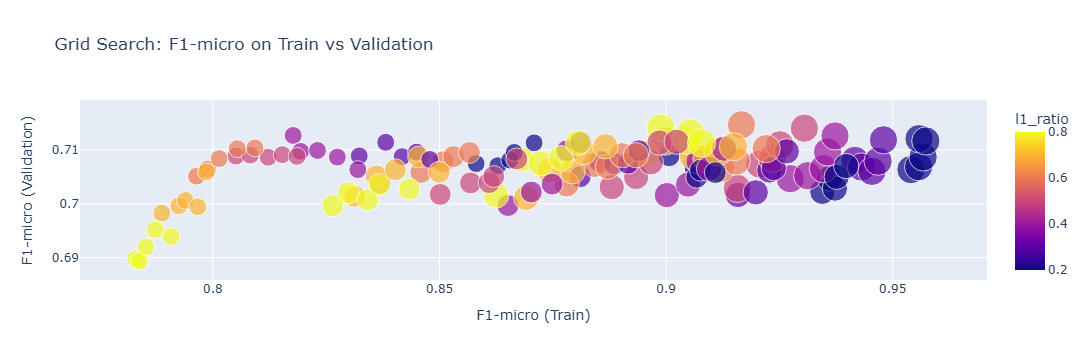

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [36]:
# -----------------------------
# Label columns
# -----------------------------
label_cols = ["Attitude_Towards_Students", "Campus_conditions", "Corruption",
              "Academic_Process_Management", "Education_Quality"]

# -----------------------------
# Load precomputed embeddings (self-supervised)
# -----------------------------
val_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/val_embeddings.npy")


X_emb_sparse = csr_matrix(val_emb)
y_labeled = val_df[label_cols].values

# -----------------------------
# Grid parameters
# -----------------------------
min_dfs = [10, 12, 15, 17, 20]
l1_ratios = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
Cs = [1, 1.5, 2, 2.5]

# -----------------------------
# Store results
# -----------------------------
results = {"min_df": [], "l1_ratio": [], "C": [], "f1_micro_train": [], "f1_micro_val": []}

# -----------------------------
# Grid search loop
# -----------------------------
for min_df, l1_ratio, C in product(min_dfs, l1_ratios, Cs):
    print(f"Running min_df={min_df}, l1_ratio={l1_ratio}, C={C}")

    # 1. TF-IDF vectorization
    vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=10000, min_df=min_df)
    vectorizer.fit(full_df["Lemmatized_Text"])
    X_tfidf = vectorizer.transform(val_df["Lemmatized_Text"])

    # 2. Combine TF-IDF + embeddings
    X_combined = hstack([X_tfidf, X_emb_sparse])

    # 3. K-Fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    f1_train_list, f1_val_list = [], []

    for tr_idx, val_idx in kf.split(X_combined):
        X_tr, X_val_fold = X_combined[tr_idx], X_combined[val_idx]
        y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

        clf = OneVsRestClassifier(
            LogisticRegression(
                max_iter=3000,
                solver="saga",
                class_weight="balanced",
                penalty="elasticnet",
                l1_ratio=l1_ratio,
                C=C,
                random_state=42
            )
        )
        clf.fit(X_tr, y_tr)
        y_tr_pred = clf.predict(X_tr)
        y_val_pred = clf.predict(X_val_fold)

        f1_train_list.append(f1_score(y_tr, y_tr_pred, average="micro"))
        f1_val_list.append(f1_score(y_val_fold, y_val_pred, average="micro"))

    # 4. Save averaged results
    results["min_df"].append(min_df)
    results["l1_ratio"].append(l1_ratio)
    results["C"].append(C)
    results["f1_micro_train"].append(np.mean(f1_train_list))
    results["f1_micro_val"].append(np.mean(f1_val_list))

# -----------------------------
# Plotting (optional)
# Convert results dictionary to DataFrame
df_results = pd.DataFrame(results)

# Create interactive scatter plot
fig = px.scatter(
    df_results,
    x="f1_micro_train",         # X-axis: F1-micro on training set
    y="f1_micro_val",           # Y-axis: F1-micro on validation set
    color="l1_ratio",           # Color points by l1_ratio
    size="C",                   # Size points by C parameter
    hover_data=["min_df", "l1_ratio", "C"],  # Show these values when hovering
    title="Grid Search: F1-micro on Train vs Validation"
)

# Update axis titles
fig.update_layout(
    xaxis_title="F1-micro (Train)",
    yaxis_title="F1-micro (Validation)"
)

# Show interactive plot in Colab / Jupyter
fig.show()

# -----------------------------
# Optional: Save static PNG for GitHub
# -----------------------------
# Install kaleido once if not installed: !pip install -q kaleido
fig.write_image("grid_search_scatter.png")

# -----------------------------
# Optional: Display a table of results under the plot
# -----------------------------
# This helps to see which hyperparameter combination corresponds to each point
display(df_results[['f1_micro_train','f1_micro_val','min_df','l1_ratio','C']])


## 🧩 **Grid Search Conclusion**

The **best hyperparameters** for the **hybrid model** (TF-IDF + SentenceTransformer embeddings) were selected as:  

- **min_df = 10**  
- **C = 1**  
- **l1_ratio = 0.4**  

These parameters were chosen to balance **model performance** and the **risk of overfitting**.  

With this configuration:  
- **F1-micro on validation ≈ 0.71**  
- **F1-micro on train ≈ 0.81**  

This indicates a strong model with **good generalization**, while still capturing important patterns from the training data.

#### Check model quality on validation set

In [8]:
# -----------------------------
# Label columns
# -----------------------------
label_cols = ["Attitude_Towards_Students", "Campus_conditions", "Corruption",
              "Academic_Process_Management", "Education_Quality"]

# -----------------------------
# Load precomputed embeddings
# -----------------------------
val_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/val_embeddings.npy")
X_emb_sparse = csr_matrix(val_emb)
y_labeled = val_df[label_cols].values

# -----------------------------
# TF-IDF vectorization
# -----------------------------
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=10)
vectorizer.fit(full_df["Lemmatized_Text"])
X_tfidf = vectorizer.transform(val_df["Lemmatized_Text"])

# -----------------------------
# Combine TF-IDF + embeddings
# -----------------------------
X_combined = hstack([X_tfidf, X_emb_sparse])

# -----------------------------
# K-Fold CV (без ручних порогів)
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all = []
y_pred_all = []

for tr_idx, val_idx in kf.split(X_combined):
    X_tr, X_val_fold = X_combined[tr_idx], X_combined[val_idx]
    y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.4,
            C=1,
            random_state=42
        )
    )

    clf.fit(X_tr, y_tr)

    # Прогноз без ручних порогів (стандартний 0.5 усередині predict)
    y_val_pred = clf.predict(X_val_fold)

    # Збираємо результати
    y_val_all.append(y_val_fold)
    y_pred_all.append(y_val_pred)

# -----------------------------
# Aggregate results across folds
# -----------------------------
y_val_all = np.vstack(y_val_all)
y_pred_all = np.vstack(y_pred_all)

print("\n=== CV Classification Report (aggregated) ===")
print(classification_report(y_val_all, y_pred_all, target_names=label_cols, zero_division=0))

cv_micro = f1_score(y_val_all, y_pred_all, average="micro")
print(f"Aggregated CV micro-F1: {cv_micro:.4f}")



=== CV Classification Report (aggregated) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.62      0.70      0.65       145
          Campus_conditions       0.70      0.74      0.72       108
                 Corruption       0.76      0.76      0.76       133
Academic_Process_Management       0.64      0.75      0.69       130
          Education_Quality       0.70      0.79      0.74       184

                  micro avg       0.68      0.75      0.71       700
                  macro avg       0.68      0.75      0.71       700
               weighted avg       0.68      0.75      0.71       700
                samples avg       0.72      0.79      0.72       700

Aggregated CV micro-F1: 0.7129


#### Check model quality on training/test sets

In [23]:

# ==========================================
# BLOCK 1: data preparation
# ==========================================
# 1. Label columns
# -----------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# -----------------------
# 2. TF-IDF features
# -----------------------
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=10
)
vectorizer.fit(full_df["Lemmatized_Text"])
X_train_tfidf = vectorizer.transform(train_df["Lemmatized_Text"])
X_test_tfidf  = vectorizer.transform(test_df["Lemmatized_Text"])

# -----------------------
# 3. Load sentence embeddings
# -----------------------
train_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/train_embeddings.npy")
test_emb  = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/test_embeddings.npy")

# Перетворюємо embeddings у sparse
X_train_emb_sparse = csr_matrix(train_emb)
X_test_emb_sparse  = csr_matrix(test_emb)

# Об'єднуємо TF-IDF + embeddings
X_train_combined = hstack([X_train_tfidf, X_train_emb_sparse])
X_test_combined  = hstack([X_test_tfidf, X_test_emb_sparse])

# Мітки
y_train = train_df[label_cols].values
y_test  = test_df[label_cols].values

# ==========================================
# BLOCK 2: Train classifier
# ==========================================
clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=0.4,
        C=1,
        random_state=42
    )
)

clf.fit(X_train_combined, y_train)

# ==========================================
# BLOCK 3: Evaluate
# ==========================================
# --- Train ---
y_train_pred = clf.predict(X_train_combined)
print("\n=== TRAIN SET RESULTS ===")
print(classification_report(y_train, y_train_pred, target_names=label_cols, digits=2))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred, average='micro', zero_division=0):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred, average='macro', zero_division=0):.3f}")

# --- Test ---
y_test_pred = clf.predict(X_test_combined)
print("\n=== TEST SET RESULTS ===")
print(classification_report(y_test, y_test_pred, target_names=label_cols, digits=2))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred, average='micro', zero_division=0):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.3f}")

# ==========================================
# BLOCK 4: Save models
# ==========================================
os.makedirs("models", exist_ok=True)
joblib.dump(clf, "models/logreg_classifier_tfidf_emb.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

print("\n✅ Classifier saved to: models/logreg_classifier_tfidf_emb.pkl")
print("✅ TF-IDF vectorizer saved to: models/tfidf_vectorizer.pkl")



=== TRAIN SET RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.79      0.84      0.82       205
          Campus_conditions       0.74      0.93      0.82       108
                 Corruption       0.78      0.94      0.85       133
Academic_Process_Management       0.81      0.86      0.83       190
          Education_Quality       0.76      0.91      0.83       184

                  micro avg       0.78      0.89      0.83       820
                  macro avg       0.78      0.90      0.83       820
               weighted avg       0.78      0.89      0.83       820
                samples avg       0.82      0.91      0.84       820

Train Micro F1: 0.830
Train Macro F1: 0.831

=== TEST SET RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.59      0.61      0.60        31
          Campus_conditions       0.77      0.79      0.78        29
  

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.



## 🧩 **Conclusion**

> **💡 Note:**  
> Training on the **hybrid feature set** combining *TF-IDF* and *SentenceTransformer embeddings*  
> yields **better performance** than training on **embeddings alone**.

- **Hybrid model** achieves **Micro F1 ≈ 0.72** and **Macro F1 ≈ 0.72**   
- **Embeddings only:** Micro F1 ≈ 0.72, Macro F1 ≈ 0.71  

  **Note:** The improvement of the hybrid model is particularly visible in **Academic_Process_Management:** F1-score improves from 0.62 → 0.71  

- **Attitude_Towards_Students:** remains a challenging category, F1-score did not improve and is 0.60